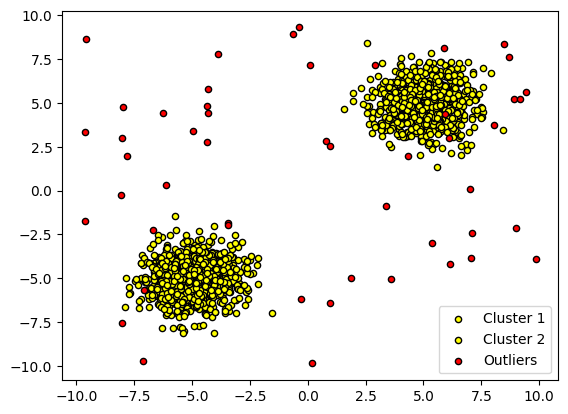

In [2]:
import matplotlib.pyplot as plt
import numpy as np

n_samples, n_outliers = 1000, 50
rng = np.random.RandomState()
cluster1 = rng.randn(n_samples, 2) - 5
cluster2 = rng.randn(n_samples, 2) + 5
outliers = rng.uniform(low=-10, high=10, size=(n_outliers, 2))
scatter = plt.scatter(cluster1[:, 0], cluster1[:, 1], color='yellow', s=20, label='Cluster 1', edgecolors='k')
scatter = plt.scatter(cluster2[:, 0], cluster2[:, 1], color='yellow', s=20, label='Cluster 2', edgecolors='k')
scatter = plt.scatter(outliers[:, 0], outliers[:, 1], color='red', s=20, label='Outliers', edgecolors='k')
plt.legend()
plt.show()

-0.6811001744483708
[-0.43749314 -0.41714577 -0.50069102 ... -0.73936916 -0.71561614
 -0.62230947]


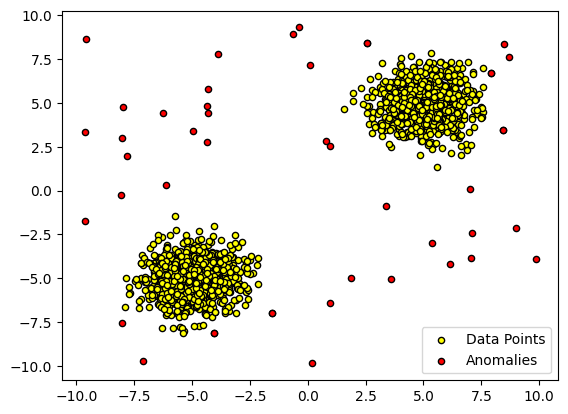

In [3]:
from sklearn.ensemble import IsolationForest


all = np.vstack([cluster1, cluster2, outliers])
only_clusters = np.vstack([cluster1, cluster2])

clf = IsolationForest(contamination=0.05)
clf.fit(all)

point = np.array([[0.0, 0.0]])
score = clf.score_samples(point)
print(score[0])

# predict method
# prediction = clf.predict(all)
# anomaly = all[prediction == -1]

# custom thresholding
scores = clf.score_samples(all)
print(scores)
threshold = np.percentile(scores, 2)
anomaly = all[scores < threshold]

plt.scatter(only_clusters[:, 0], only_clusters[:, 1], color='yellow', s=20, label='Data Points', edgecolors='k')
plt.scatter(anomaly[:, 0], anomaly[:, 1], color='red', s=20, label='Anomalies', edgecolors='k')
plt.legend()
plt.show()